In [1]:
import numpy as np
import pandas as pd

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load modelling-ready dataset
df_model = pd.read_csv("../data/processed/df_young_model_ready_2024.csv")

# Define target + protected attrs
y = df_model["high_risk"].astype(int)

A = df_model[["sex_of_driver", "age_band_of_driver"]].copy()

# Features (exclude target + protected)
X = df_model.drop(columns=["high_risk", "sex_of_driver", "age_band_of_driver"])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, A,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("y_test distribution:", np.bincount(y_test))

Train: (10700, 49) Test: (2676, 49)
y_test distribution: [1967  709]


## A) Logistic Regression (scaled + class-weight balanced)

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_bal = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))
])

lr_bal.fit(X_train, y_train)
y_proba_lr = lr_bal.predict_proba(X_test)[:, 1]

## B) Random Forest (baseline model we used in notebook 04)

In [3]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

## C) XGBoost (same as the baseline settings in notebook 04)

In [4]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

## Threshold Sweep Analysis


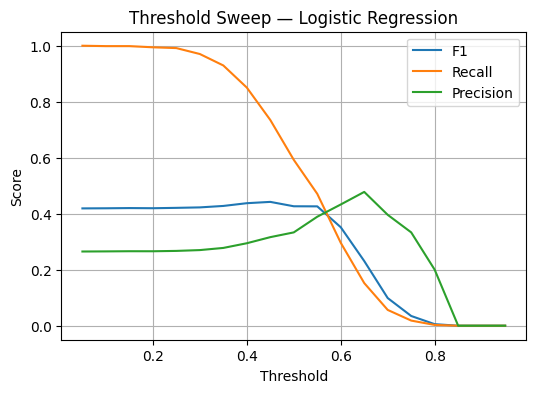

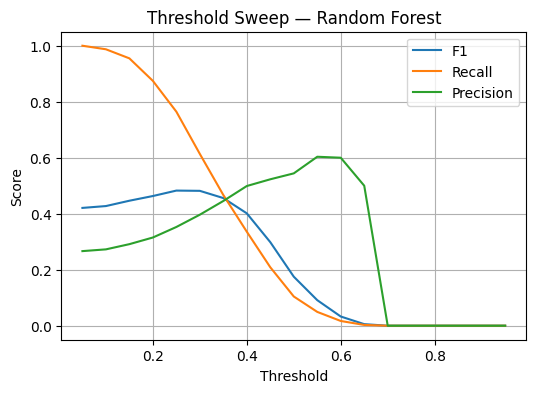

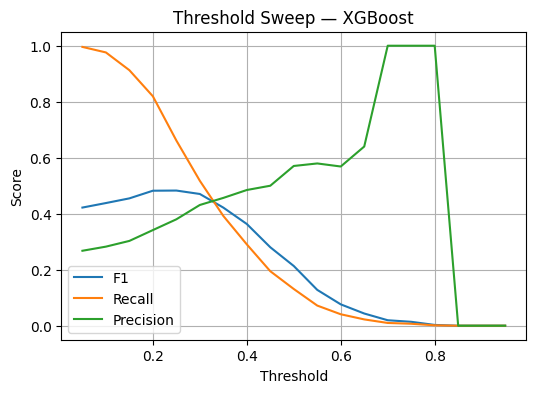

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.linspace(0.05, 0.95, 19)

def threshold_sweep(y_true, y_proba, model_name):

    f1_scores = []
    recalls = []
    precisions = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        f1_scores.append(f1_score(y_true, y_pred))
        recalls.append(recall_score(y_true, y_pred))
        precisions.append(precision_score(y_true, y_pred, zero_division=0))

    plt.figure(figsize=(6,4))
    plt.plot(thresholds, f1_scores, label="F1")
    plt.plot(thresholds, recalls, label="Recall")
    plt.plot(thresholds, precisions, label="Precision")

    plt.title(f"Threshold Sweep — {model_name}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)

threshold_sweep(y_test, y_proba_lr, "Logistic Regression")
threshold_sweep(y_test, y_proba_rf, "Random Forest")
threshold_sweep(y_test, y_proba_xgb, "XGBoost")

### Threshold Selection

The default classification threshold for most machine learning models is 0.5.  
However, this dataset is moderately imbalanced, with significantly more low-risk
drivers than high-risk drivers. Using the default threshold therefore leads to
very low recall for the high-risk class, meaning many risky drivers would not be
identified.

To address this, a threshold sweep was performed for each model by evaluating
precision, recall, and F1-score across a range of thresholds. The results show
how lowering the threshold increases recall (detecting more high-risk drivers)
while typically reducing precision.

Based on the trade-offs observed in the threshold sweep plots:

- **Logistic Regression:** A threshold of **0.5** was retained because it provided a
  balanced trade-off between precision and recall without significantly harming
  overall performance.

- **Random Forest:** A threshold of **0.3** was selected because it substantially
  increased recall and improved the F1-score compared with the default threshold.

- **XGBoost:** A threshold of **0.3** was also selected as it provided a good
  balance between identifying high-risk drivers and maintaining acceptable
  precision.

These thresholds were therefore used in the subsequent fairness analysis to
generate final binary predictions.

In [5]:
THRESHOLDS = {
    "LR_balanced": 0.5,
    "RandomForest": 0.3,
    "XGBoost": 0.3
}

probas = {
    "LR_balanced": y_proba_lr,
    "RandomForest": y_proba_rf,
    "XGBoost": y_proba_xgb
}

preds = {name: (p >= THRESHOLDS[name]).astype(int) for name, p in probas.items()}

In [6]:
from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference, equalized_odds_difference
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Build a clean metrics dictionary

We’ll compute:
- overall performance
- group performance by sex_of_driver and by age_band_of_driver
- fairness gaps:
    - Demographic parity difference
    - Equalized odds difference
    - selection rate by group

In [7]:
metrics = {
    "accuracy": accuracy_score,
    "precision": lambda yt, yp: precision_score(yt, yp, zero_division=0),
    "recall": recall_score,
    "f1": lambda yt, yp: f1_score(yt, yp, zero_division=0),
    "selection_rate": selection_rate
}

### A) Fairness by sex

In [8]:
def fairness_report(model_name, y_true, y_pred, sensitive_series, sensitive_name):
    mf = MetricFrame(
        metrics=metrics,
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive_series
    )
    print(f"\n=== {model_name} | Sensitive attribute: {sensitive_name} ===")
    print("Overall:")
    print(mf.overall)
    print("\nBy group:")
    print(mf.by_group)

    # Fairness gaps
    dp_diff = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive_series)
    eo_diff = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive_series)

    print(f"\nDemographic parity difference: {dp_diff:.4f}")
    print(f"Equalized odds difference:     {eo_diff:.4f}")

for name, y_pred in preds.items():
    fairness_report(
        model_name=name,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_series=A_test["sex_of_driver"],
        sensitive_name="sex_of_driver"
    )


=== LR_balanced | Sensitive attribute: sex_of_driver ===
Overall:
accuracy          0.578102
precision         0.333333
recall            0.592384
f1                0.426612
selection_rate    0.470852
dtype: float64

By group:
               accuracy  precision    recall        f1  selection_rate
sex_of_driver                                                         
1              0.571656   0.359869  0.600000  0.449898        0.486730
2              0.593434   0.262391  0.566038  0.358566        0.433081

Demographic parity difference: 0.0536
Equalized odds difference:     0.0403

=== RandomForest | Sensitive attribute: sex_of_driver ===
Overall:
accuracy          0.650224
precision         0.396536
recall            0.613540
f1                0.481728
selection_rate    0.409940
dtype: float64

By group:
               accuracy  precision    recall        f1  selection_rate
sex_of_driver                                                         
1              0.634820   0.418052  0.64

### B) Fairness by age band

In [9]:
for name, y_pred in preds.items():
    fairness_report(
        model_name=name,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_series=A_test["age_band_of_driver"],
        sensitive_name="age_band_of_driver"
    )


=== LR_balanced | Sensitive attribute: age_band_of_driver ===
Overall:
accuracy          0.578102
precision         0.333333
recall            0.592384
f1                0.426612
selection_rate    0.470852
dtype: float64

By group:
                    accuracy  precision    recall        f1  selection_rate
age_band_of_driver                                                         
4                   0.547841   0.330781  0.690096  0.447205        0.552921
5                   0.602007   0.336079  0.515152  0.406780        0.406020

Demographic parity difference: 0.1469
Equalized odds difference:     0.1749

=== RandomForest | Sensitive attribute: age_band_of_driver ===
Overall:
accuracy          0.650224
precision         0.396536
recall            0.613540
f1                0.481728
selection_rate    0.409940
dtype: float64

By group:
                    accuracy  precision    recall        f1  selection_rate
age_band_of_driver                                                         


### C) Intersectional Fairness (Sex × Age)

In addition to analysing fairness across individual protected attributes,
we examine intersectional groups formed by combining sex_of_driver and
age_band_of_driver.

Intersectional fairness analysis helps identify whether certain demographic
subgroups experience different model behaviour that may not be visible when
examining attributes independently.

In [11]:
# Create intersection groups (sex × age)
intersection_groups = (
    A_test["sex_of_driver"].astype(str) +
    "_age_" +
    A_test["age_band_of_driver"].astype(str)
)

In [12]:
for name, y_pred in preds.items():
    fairness_report(
        model_name=name,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_series=intersection_groups,
        sensitive_name="sex × age"
    )


=== LR_balanced | Sensitive attribute: sex × age ===
Overall:
accuracy          0.578102
precision         0.333333
recall            0.592384
f1                0.426612
selection_rate    0.470852
dtype: float64

By group:
                     accuracy  precision    recall        f1  selection_rate
sensitive_feature_0                                                         
1_age_4              0.542453   0.352818  0.684211  0.465565        0.564858
1_age_5              0.595560   0.367580  0.531353  0.434548        0.422780
2_age_4              0.561562   0.270115  0.712121  0.391667        0.522523
2_age_5              0.616558   0.254438  0.462366  0.328244        0.368192

Demographic parity difference: 0.1967
Equalized odds difference:     0.2498

=== RandomForest | Sensitive attribute: sex × age ===
Overall:
accuracy          0.650224
precision         0.396536
recall            0.613540
f1                0.481728
selection_rate    0.409940
dtype: float64

By group:
            

### Interpretation
The intersectional fairness analysis evaluates model behaviour across
combined demographic groups defined by both `sex_of_driver` and
`age_band_of_driver`. This results in four subgroups representing
different combinations of driver sex and age band.

The results show that fairness disparities become more noticeable when
considering intersectional groups rather than analysing each attribute
separately. In particular, differences can be observed in the selection
rates and recall values across the four demographic combinations,
indicating that the models do not treat all subgroups identically.

Across the evaluated models, Random Forest exhibits the largest fairness
gaps, with the highest demographic parity difference and equalized odds
difference. Logistic Regression shows slightly smaller disparities,
while XGBoost demonstrates a moderate level of disparity between groups.

These findings highlight the importance of performing intersectional
fairness analysis, as biases affecting specific demographic subgroups
may not be visible when evaluating protected attributes individually.
Overall, the results suggest that while the models achieve reasonable
predictive performance, some differences in prediction behaviour across
demographic subgroups remain present.


## Model Performance and Fairness Comparison

In [14]:
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

summary_rows = []

for name, y_pred in preds.items():

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "DP Difference (sex)": demographic_parity_difference(
            y_test, y_pred, sensitive_features=A_test["sex_of_driver"]
        ),
        "EO Difference (sex)": equalized_odds_difference(
            y_test, y_pred, sensitive_features=A_test["sex_of_driver"]
        ),
        "DP Difference (age)": demographic_parity_difference(
            y_test, y_pred, sensitive_features=A_test["age_band_of_driver"]
        ),
        "EO Difference (age)": equalized_odds_difference(
            y_test, y_pred, sensitive_features=A_test["age_band_of_driver"]
        )
    }

    summary_rows.append(row)

summary_table = pd.DataFrame(summary_rows)

summary_table.round(3).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,DP Difference (sex),EO Difference (sex),DP Difference (age),EO Difference (age)
0,LR_balanced,0.578,0.333,0.592,0.427,0.054,0.040,0.147,0.175
1,RandomForest,0.650,0.397,0.614,0.482,0.125,0.118,0.133,0.166
2,XGBoost,0.691,0.431,0.518,0.471,0.136,0.124,0.089,0.149


### Interpretation of Model Performance and Fairness

The table above summarises both predictive performance and fairness metrics across the evaluated models.

XGBoost achieves the highest overall predictive performance, with the largest accuracy (0.691) and precision (0.431). Random Forest performs moderately well, while Logistic Regression shows the lowest predictive performance among the evaluated models.

However, the fairness metrics reveal some differences across demographic groups. Logistic Regression shows the smallest disparity across sex, while XGBoost exhibits the smallest disparity across age groups. Random Forest demonstrates slightly larger fairness gaps compared with the other models.

Overall, the results highlight a common trade-off between predictive performance and algorithmic fairness. While XGBoost provides the best predictive accuracy, it does not always produce the most balanced outcomes across demographic groups. This illustrates the importance of evaluating both performance and fairness when developing machine learning models for decision-making contexts such as insurance risk
assessment.

## Confidence intervals / stability (bootstrap on the test set)

In [15]:
import numpy as np
import pandas as pd

from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

def bootstrap_fairness_gaps(
    y_true, y_pred, sensitive_features, n_boot=200, random_state=42
):
    """
    Returns bootstrap distribution + 95% CI for DP diff and EO diff.
    """
    rng = np.random.default_rng(random_state)
    n = len(y_true)

    dp_vals = []
    eo_vals = []

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    sensitive_features = np.asarray(sensitive_features)

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)  # sample WITH replacement
        yt = y_true[idx]
        yp = y_pred[idx]
        sf = sensitive_features[idx]

        dp_vals.append(demographic_parity_difference(yt, yp, sensitive_features=sf))
        eo_vals.append(equalized_odds_difference(yt, yp, sensitive_features=sf))

    dp_vals = np.array(dp_vals)
    eo_vals = np.array(eo_vals)

    def ci(arr):
        return np.mean(arr), np.percentile(arr, 2.5), np.percentile(arr, 97.5), np.std(arr)

    dp_mean, dp_lo, dp_hi, dp_sd = ci(dp_vals)
    eo_mean, eo_lo, eo_hi, eo_sd = ci(eo_vals)

    return {
        "dp_mean": dp_mean, "dp_ci_low": dp_lo, "dp_ci_high": dp_hi, "dp_sd": dp_sd,
        "eo_mean": eo_mean, "eo_ci_low": eo_lo, "eo_ci_high": eo_hi, "eo_sd": eo_sd
    }

# --- build intersection attribute (sex × age) ---
A_test_intersection = (A_test["sex_of_driver"].astype(str) + "_age_" + A_test["age_band_of_driver"].astype(str))

BOOTSTRAP_N = 200  # you can set 500 if you want

rows = []
for model_name, y_pred in preds.items():
    # sex
    sex_stats = bootstrap_fairness_gaps(
        y_test, y_pred, A_test["sex_of_driver"], n_boot=BOOTSTRAP_N, random_state=42
    )
    # age
    age_stats = bootstrap_fairness_gaps(
        y_test, y_pred, A_test["age_band_of_driver"], n_boot=BOOTSTRAP_N, random_state=42
    )
    # intersection
    int_stats = bootstrap_fairness_gaps(
        y_test, y_pred, A_test_intersection, n_boot=BOOTSTRAP_N, random_state=42
    )

    rows.append({
        "Model": model_name,

        "DP(sex) mean": sex_stats["dp_mean"],
        "DP(sex) 95% CI": f"[{sex_stats['dp_ci_low']:.3f}, {sex_stats['dp_ci_high']:.3f}]",
        "EO(sex) mean": sex_stats["eo_mean"],
        "EO(sex) 95% CI": f"[{sex_stats['eo_ci_low']:.3f}, {sex_stats['eo_ci_high']:.3f}]",

        "DP(age) mean": age_stats["dp_mean"],
        "DP(age) 95% CI": f"[{age_stats['dp_ci_low']:.3f}, {age_stats['dp_ci_high']:.3f}]",
        "EO(age) mean": age_stats["eo_mean"],
        "EO(age) 95% CI": f"[{age_stats['eo_ci_low']:.3f}, {age_stats['eo_ci_high']:.3f}]",

        "DP(int) mean": int_stats["dp_mean"],
        "DP(int) 95% CI": f"[{int_stats['dp_ci_low']:.3f}, {int_stats['dp_ci_high']:.3f}]",
        "EO(int) mean": int_stats["eo_mean"],
        "EO(int) 95% CI": f"[{int_stats['eo_ci_low']:.3f}, {int_stats['eo_ci_high']:.3f}]",
    })

bootstrap_ci_table = pd.DataFrame(rows)

# nicer formatting for display
float_cols = [c for c in bootstrap_ci_table.columns if c.endswith(" mean")]
bootstrap_ci_table[float_cols] = bootstrap_ci_table[float_cols].round(3)

bootstrap_ci_table

,Model,DP(sex) mean,DP(sex) 95% CI,EO(sex) mean,EO(sex) 95% CI,DP(age) mean,DP(age) 95% CI,EO(age) mean,EO(age) 95% CI,DP(int) mean,DP(int) 95% CI,EO(int) mean,EO(int) 95% CI
0,LR_balanced,0.053,"[0.020, 0.095]",0.058,"[0.014, 0.119]",0.146,"[0.110, 0.175]",0.178,"[0.121, 0.239]",0.197,"[0.149, 0.248]",0.268,"[0.173, 0.377]"
1,RandomForest,0.125,"[0.092, 0.170]",0.131,"[0.077, 0.210]",0.132,"[0.100, 0.163]",0.166,"[0.115, 0.229]",0.255,"[0.203, 0.309]",0.325,"[0.219, 0.453]"
2,XGBoost,0.137,"[0.103, 0.183]",0.138,"[0.085, 0.208]",0.087,"[0.055, 0.123]",0.145,"[0.071, 0.211]",0.217,"[0.169, 0.271]",0.271,"[0.174, 0.391]"


### Confidence Intervals for Fairness Metrics

To evaluate the stability of the fairness metrics, bootstrap resampling was
performed on the test set using 200 resamples. For each resample, the
demographic parity difference (DP) and equalized odds difference (EO)
were recomputed, allowing the estimation of 95% confidence intervals.

The results indicate that the fairness gaps observed earlier are
relatively stable across resampled datasets. The confidence intervals
are reasonably narrow for most metrics, suggesting that the disparities
are not simply due to random variation in the test split.

Across the evaluated models, Logistic Regression shows the smallest
fairness disparities across sex, while XGBoost demonstrates slightly
smaller disparities across age groups. Random Forest generally exhibits
larger disparities compared with the other models.

When analysing intersectional groups formed by combining sex and age,
the fairness gaps increase for all models. This indicates that certain
demographic subgroups experience different prediction outcomes that are
not fully visible when analysing each attribute independently.

Overall, the bootstrap analysis confirms that the fairness differences
identified in the earlier evaluation are consistent and not solely
caused by sampling variability.